# 02 - Train a Nim Transformer Move Model

This notebook trains the attention-based move model.

The pipeline is:

```text
board bits -> XOR predictor -> predicted balance bits
balance query + pile keys/values -> attention -> selected pile
context + balance embedding -> target-size head -> stones left after move
```

Training uses the true Nim-sum as the conditioning target. Evaluation uses the XOR predictor saved by notebook 01.

The canonical training move is chosen as:

1. Try every legal move that restores balance.
2. Choose the move that removes the most stones.
3. Break ties by lower pile index.

Example `[2,2,3] -> [2,2,0]`.

In [1]:
from pathlib import Path
from dataclasses import dataclass, asdict
from itertools import product
import os
import random

# os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/matplotlib_config").resolve()))
# Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
@dataclass
class NimPipelineConfig:
    num_piles: int = 3
    max_stones: int = 7
    d_model: int = 32
    batch_size: int = 64
    epochs: int = 220
    learning_rate: float = 0.01
    test_fraction: float = 0.2
    seed: int = 42
    xor_checkpoint_path: str = "checkpoints/nim_xor_predictor.pt"
    move_checkpoint_path: str = "checkpoints/nim_transformer_move_model.pt"

    @property
    def bit_width(self):
        return max(1, self.max_stones.bit_length())

    @property
    def flat_input_dim(self):
        return self.num_piles * self.bit_width


CONFIG = NimPipelineConfig(num_piles=3, max_stones=7)
Path(CONFIG.move_checkpoint_path).parent.mkdir(parents=True, exist_ok=True)
CONFIG

NimPipelineConfig(num_piles=3, max_stones=7, d_model=32, batch_size=64, epochs=220, learning_rate=0.01, test_fraction=0.2, seed=42, xor_checkpoint_path='checkpoints/nim_xor_predictor.pt', move_checkpoint_path='checkpoints/nim_transformer_move_model.pt')

In [3]:
def int_to_bits(value, width):
    return [int(x) for x in format(int(value), f"0{width}b")]


def bits_to_int(bits):
    return int("".join(str(int(round(float(b)))) for b in bits), 2)


def nim_sum(piles):
    value = 0
    for pile in piles:
        value ^= int(pile)
    return value


def board_to_bit_rows(piles, bit_width):
    return [int_to_bits(pile, bit_width) for pile in piles]


def board_to_flat_bits(piles, bit_width):
    return [bit for row in board_to_bit_rows(piles, bit_width) for bit in row]


def all_boards(num_piles, max_stones, include_terminal=False):
    for piles in product(range(max_stones + 1), repeat=num_piles):
        if not include_terminal and all(p == 0 for p in piles):
            continue
        yield list(piles)


def legal_balancing_moves(piles):
    moves = []
    for pile_idx, pile_size in enumerate(piles):
        for target_size in range(pile_size):
            after = list(piles)
            after[pile_idx] = target_size
            if nim_sum(after) == 0:
                moves.append(
                    {
                        "pile": pile_idx,
                        "target": target_size,
                        "after": after,
                        "removed": pile_size - target_size,
                    }
                )
    return moves


def canonical_optimal_move(piles):
    if nim_sum(piles) == 0:
        return None
    moves = legal_balancing_moves(piles)
    if not moves:
        return None
    return sorted(moves, key=lambda m: (-m["removed"], m["pile"], m["target"]))[0]


print(canonical_optimal_move([2, 2, 3]))

{'pile': 2, 'target': 0, 'after': [2, 2, 0], 'removed': 3}


In [4]:
class NimXorPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, bit_width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, bit_width),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def load_xor_predictor(path):
    checkpoint = torch.load(path, map_location="cpu") # change this to gpu if you have gpu support
    xor_config = checkpoint["config"]
    bit_width = max(1, int(xor_config["max_stones"]).bit_length())
    model = NimXorPredictor(
        input_dim=int(xor_config["num_piles"]) * bit_width,
        hidden_dim=int(xor_config["hidden_dim"]),
        bit_width=bit_width,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, xor_config, checkpoint


def predict_xor_bits(xor_model, piles, bit_width):
    x = torch.tensor([board_to_flat_bits(piles, bit_width)], dtype=torch.float32)
    with torch.no_grad():
        probabilities = xor_model(x).squeeze(0)
    bits = (probabilities >= 0.5).int().tolist()
    return {
        "probabilities": probabilities.tolist(),
        "bits": bits,
        "value": bits_to_int(bits),
    }


xor_model, xor_config, xor_checkpoint = load_xor_predictor(CONFIG.xor_checkpoint_path)
predict_xor_bits(xor_model, [2, 2, 3], CONFIG.bit_width)

{'probabilities': [7.442372861987678e-06,
  0.9999527931213379,
  0.9999804496765137],
 'bits': [0, 1, 1],
 'value': 3}

In [5]:
class NimMoveDataset(Dataset):
    def __init__(self, config):
        self.config = config
        self.samples = []

        for piles in all_boards(config.num_piles, config.max_stones, include_terminal=False):
            xor_value = nim_sum(piles)
            if xor_value == 0:
                continue

            move = canonical_optimal_move(piles)
            if move is None:
                continue

            self.samples.append(
                {
                    "piles": torch.tensor(board_to_bit_rows(piles, config.bit_width), dtype=torch.float32),
                    "xor_target": torch.tensor(int_to_bits(xor_value, config.bit_width), dtype=torch.float32),
                    "label_idx": torch.tensor(move["pile"], dtype=torch.long),
                    "label_bits": torch.tensor(int_to_bits(move["target"], config.bit_width), dtype=torch.float32),
                    "raw_piles": piles,
                    "xor_value": xor_value,
                    "move": move,
                }
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


dataset = NimMoveDataset(CONFIG)
test_size = max(1, int(len(dataset) * CONFIG.test_fraction))
train_size = len(dataset) - test_size
generator = torch.Generator().manual_seed(CONFIG.seed)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
train_loader = DataLoader(train_dataset, batch_size=CONFIG.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG.batch_size, shuffle=False)

len(dataset), dataset[0]

(448,
 {'piles': tensor([[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 1.]]),
  'xor_target': tensor([0., 0., 1.]),
  'label_idx': tensor(2),
  'label_bits': tensor([0., 0., 0.]),
  'raw_piles': [0, 0, 1],
  'xor_value': 1,
  'move': {'pile': 2, 'target': 0, 'after': [0, 0, 0], 'removed': 1}})

In [6]:
class NimTransformerMoveModel(nn.Module):
    def __init__(self, bit_width, num_piles, d_model=32):
        super().__init__()
        self.bit_width = bit_width
        self.num_piles = num_piles
        self.d_model = d_model

        self.pile_embedding = nn.Linear(bit_width, d_model)
        self.target_embedding = nn.Linear(bit_width, d_model)
        self.position_embedding = nn.Embedding(num_piles, d_model)

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.target_size_head = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.ReLU(),
            nn.Linear(d_model, bit_width),
            nn.Sigmoid(),
        )

    def forward(self, pile_bits, target_xor_bits, return_details=False):
        batch_size = pile_bits.shape[0]
        positions = torch.arange(self.num_piles, device=pile_bits.device).unsqueeze(0)
        positions = positions.expand(batch_size, self.num_piles)

        pile_emb = self.pile_embedding(pile_bits) + self.position_embedding(positions)
        target_emb = self.target_embedding(target_xor_bits)

        q = self.w_q(target_emb).unsqueeze(1)
        k = self.w_k(pile_emb)
        v = self.w_v(pile_emb)

        attention_scores = torch.bmm(q, k.transpose(1, 2)) / (self.d_model ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        context = torch.bmm(attention_weights, v).squeeze(1)

        pile_logits = attention_scores.squeeze(1)
        target_bits = self.target_size_head(torch.cat([context, target_emb], dim=-1))

        if return_details:
            return {
                "pile_logits": pile_logits,
                "target_bits": target_bits,
                "attention_weights": attention_weights,
                "context": context,
                "pile_embeddings": pile_emb,
                "target_embedding": target_emb,
                "q": q,
                "k": k,
                "v": v,
            }

        return pile_logits, target_bits, attention_weights


move_model = NimTransformerMoveModel(CONFIG.bit_width, CONFIG.num_piles, CONFIG.d_model)
criterion_index = nn.CrossEntropyLoss() # apply to attention score to select the correct pile
criterion_bits = nn.BCELoss() # loss for predicting the number of stones to have (in bits representation)
optimizer = optim.Adam(move_model.parameters(), lr=CONFIG.learning_rate)
move_model

NimTransformerMoveModel(
  (pile_embedding): Linear(in_features=3, out_features=32, bias=True)
  (target_embedding): Linear(in_features=3, out_features=32, bias=True)
  (position_embedding): Embedding(3, 32)
  (w_q): Linear(in_features=32, out_features=32, bias=True)
  (w_k): Linear(in_features=32, out_features=32, bias=True)
  (w_v): Linear(in_features=32, out_features=32, bias=True)
  (target_size_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=3, bias=True)
    (3): Sigmoid()
  )
)

In [7]:
def evaluate_move_model(model, dataset, xor_model=None, xor_source="oracle"):
    model.eval()
    pile_correct = 0
    bits_correct = 0
    move_correct = 0
    total = 0

    with torch.no_grad():
        for sample in dataset:
            pile_bits = sample["piles"].unsqueeze(0)
            if xor_source == "predicted":
                xor_info = predict_xor_bits(xor_model, sample["raw_piles"], CONFIG.bit_width)
                xor_tensor = torch.tensor([xor_info["bits"]], dtype=torch.float32)
            else:
                xor_tensor = sample["xor_target"].unsqueeze(0)

            logits, bits, _ = model(pile_bits, xor_tensor)
            predicted_pile = int(torch.argmax(logits, dim=1).item())
            rounded_bits = (bits >= 0.5).int().squeeze(0)
            predicted_target = bits_to_int(rounded_bits.tolist())

            true_pile = int(sample["label_idx"].item())
            true_target = bits_to_int(sample["label_bits"].tolist())

            pile_correct += int(predicted_pile == true_pile)
            bits_correct += int(torch.equal(rounded_bits.float(), sample["label_bits"]))
            move_correct += int(predicted_pile == true_pile and predicted_target == true_target)
            total += 1

    return {
        "pile_accuracy": pile_correct / total,
        "target_bits_accuracy": bits_correct / total,
        "full_move_accuracy": move_correct / total,
        "n": total,
    }


history = []
for epoch in range(1, CONFIG.epochs + 1):
    move_model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        logits, bits, _ = move_model(batch["piles"], batch["xor_target"])
        loss = criterion_index(logits, batch["label_idx"]) + criterion_bits(bits, batch["label_bits"])
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch == 1 or epoch % 25 == 0 or epoch == CONFIG.epochs:
        train_metrics = evaluate_move_model(move_model, train_dataset, xor_model, xor_source="oracle")
        test_oracle = evaluate_move_model(move_model, test_dataset, xor_model, xor_source="oracle")
        test_predicted = evaluate_move_model(move_model, test_dataset, xor_model, xor_source="predicted")
        row = {
            "epoch": epoch,
            "train_loss": total_loss / len(train_loader),
            "train_full_move_accuracy": train_metrics["full_move_accuracy"],
            "test_oracle_full_move_accuracy": test_oracle["full_move_accuracy"],
            "test_predicted_full_move_accuracy": test_predicted["full_move_accuracy"],
        }
        history.append(row)
        print(
            f"epoch {epoch:4d} | loss {row['train_loss']:.4f} | "
            f"train move {row['train_full_move_accuracy']:.1%} | "
            f"test oracle {row['test_oracle_full_move_accuracy']:.1%} | "
            f"test predicted-xor {row['test_predicted_full_move_accuracy']:.1%}"
        )

epoch    1 | loss 1.6285 | train move 21.4% | test oracle 18.0% | test predicted-xor 18.0%
epoch   25 | loss 0.0322 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch   50 | loss 0.0015 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch   75 | loss 0.0008 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  100 | loss 0.0005 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  125 | loss 0.0004 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  150 | loss 0.0003 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  175 | loss 0.0002 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  200 | loss 0.0002 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%
epoch  220 | loss 0.0001 | train move 100.0% | test oracle 100.0% | test predicted-xor 100.0%


In [ ]:
def save_move_checkpoint(model, config, history):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "config": asdict(config),
        "history": history,
        "architecture": "pile/position embeddings + single-head attention + MLP target-size head",
        "move_target_rule": "canonical: restore balance, remove the most stones, tie by lower pile index",
    }
    torch.save(checkpoint, config.move_checkpoint_path)
    return Path(config.move_checkpoint_path).resolve()


move_checkpoint_path = save_move_checkpoint(move_model, CONFIG, history)
move_checkpoint_path

In [9]:
def load_move_model(path):
    checkpoint = torch.load(path, map_location="cpu")
    config = NimPipelineConfig(**checkpoint["config"])
    model = NimTransformerMoveModel(config.bit_width, config.num_piles, config.d_model)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, config, checkpoint


move_model, CONFIG, move_checkpoint = load_move_model(CONFIG.move_checkpoint_path)
evaluate_move_model(move_model, test_dataset, xor_model, xor_source="predicted")

{'pile_accuracy': 1.0,
 'target_bits_accuracy': 1.0,
 'full_move_accuracy': 1.0,
 'n': 89}

In [10]:
def model_decision(piles, xor_source="predicted"):
    piles = list(piles)
    pile_bits = torch.tensor([board_to_bit_rows(piles, CONFIG.bit_width)], dtype=torch.float32)

    if xor_source == "predicted":
        xor_info = predict_xor_bits(xor_model, piles, CONFIG.bit_width)
        xor_bits = xor_info["bits"]
    else:
        xor_bits = int_to_bits(nim_sum(piles), CONFIG.bit_width)
        xor_info = {"bits": xor_bits, "value": bits_to_int(xor_bits), "probabilities": None}

    xor_tensor = torch.tensor([xor_bits], dtype=torch.float32)
    with torch.no_grad():
        details = move_model(pile_bits, xor_tensor, return_details=True)

    pile_logits = details["pile_logits"].squeeze(0)
    target_prob = details["target_bits"].squeeze(0)
    attention = details["attention_weights"].squeeze(0).squeeze(0)

    selected = int(torch.argmax(pile_logits).item())
    target_bits = (target_prob >= 0.5).int().tolist()
    target = bits_to_int(target_bits)

    after = list(piles)
    if 0 <= selected < len(after) and target < after[selected]:
        after[selected] = target
        used_rule_fallback = False
    else:
        move = canonical_optimal_move(piles)
        selected = move["pile"]
        target = move["target"]
        target_bits = int_to_bits(target, CONFIG.bit_width)
        after = move["after"]
        used_rule_fallback = True

    return {
        "piles": piles,
        "pile_bits": board_to_bit_rows(piles, CONFIG.bit_width),
        "xor": nim_sum(piles),
        "xor_bits": xor_bits,
        "xor_info": xor_info,
        "attention": attention.tolist(),
        "pile_logits": pile_logits.tolist(),
        "selected_pile": selected,
        "target_probabilities": target_prob.tolist(),
        "target_bits": target_bits,
        "target": target,
        "after": after,
        "after_xor": nim_sum(after),
        "used_rule_fallback": used_rule_fallback,
        "ground_truth": canonical_optimal_move(piles),
    }


model_decision([2, 2, 3])

{'piles': [2, 2, 3],
 'pile_bits': [[0, 1, 0], [0, 1, 0], [0, 1, 1]],
 'xor': 3,
 'xor_bits': [0, 1, 1],
 'xor_info': {'probabilities': [7.442372861987678e-06,
   0.9999527931213379,
   0.9999804496765137],
  'bits': [0, 1, 1],
  'value': 3},
 'attention': [0.0005848284927196801,
  6.37465802810766e-07,
  0.9994145631790161],
 'pile_logits': [11.979722023010254, 5.158148765563965, 19.423328399658203],
 'selected_pile': 2,
 'target_probabilities': [1.000644715531962e-06,
  4.132075446250383e-06,
  6.01841065872577e-06],
 'target_bits': [0, 0, 0],
 'target': 0,
 'after': [2, 2, 0],
 'after_xor': 0,
 'used_rule_fallback': False,
 'ground_truth': {'pile': 2, 'target': 0, 'after': [2, 2, 0], 'removed': 3}}

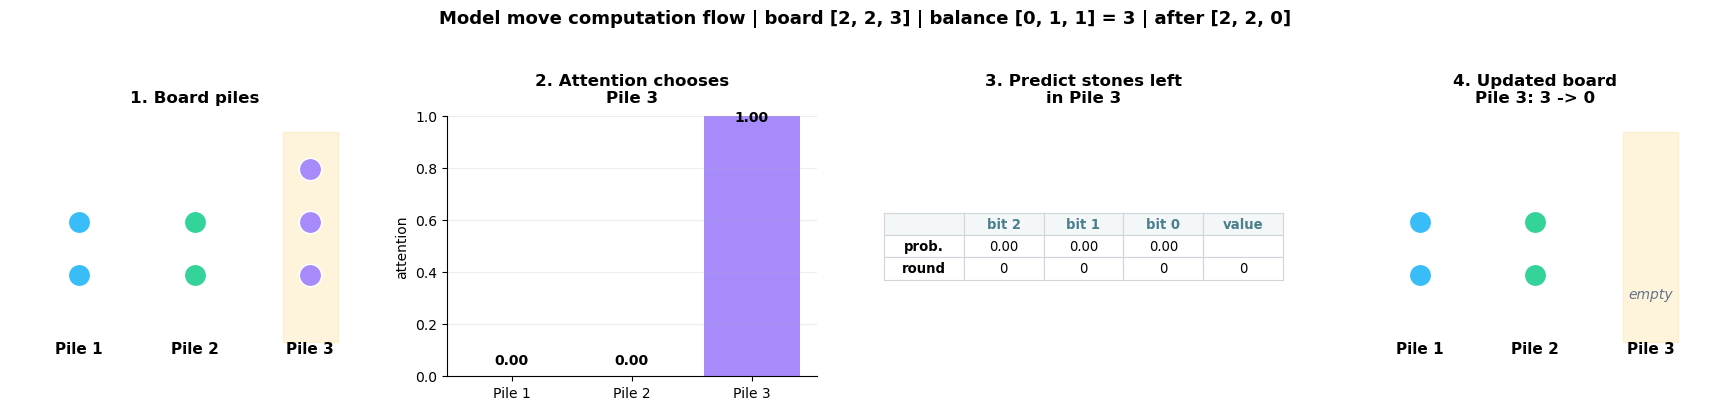

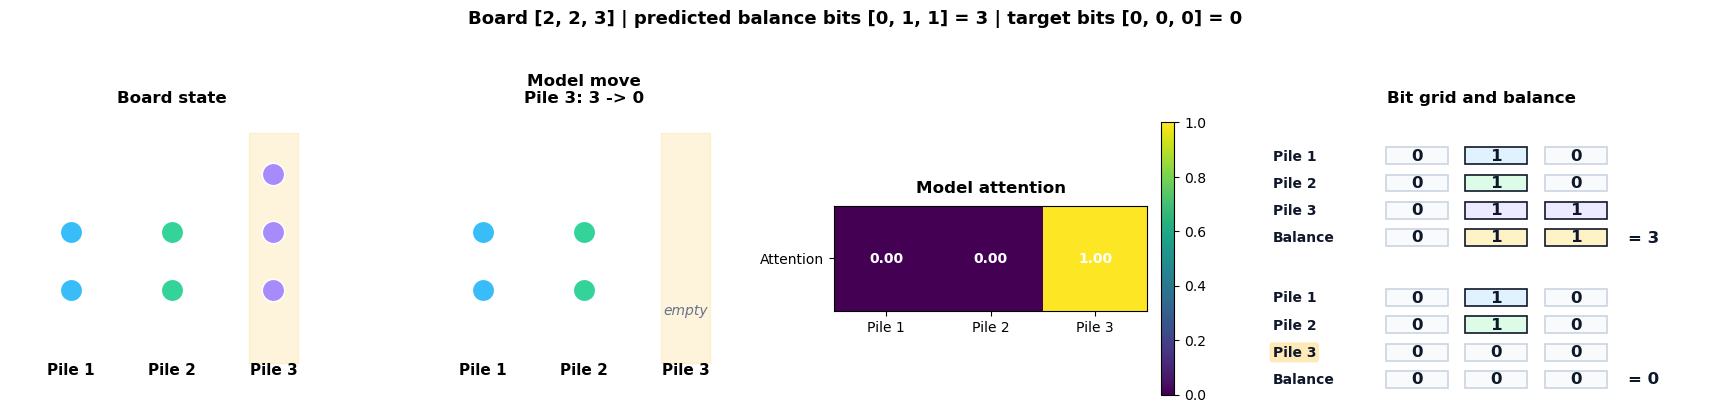

In [11]:
SLIDE_DPI = 300
PILE_COLORS = ["#38bdf8", "#34d399", "#a78bfa", "#fbbf24", "#fb7185", "#60a5fa"]
ROW_COLORS = ["#e0f2fe", "#dcfce7", "#ede9fe", "#fef3c7", "#fee2e2", "#dbeafe"]


def draw_stone_board(ax, piles, title, highlight_idx=None, max_stones=None):
    """Original slide-style pile visual: circular stones and a subtle selected-pile band."""
    piles = list(map(int, piles))
    max_stones = max_stones or max(max(piles), 1)

    for pile_idx, stones in enumerate(piles):
        x = pile_idx + 1
        if highlight_idx is not None and pile_idx == highlight_idx:
            ax.axvspan(x - 0.24, x + 0.24, ymin=0.13, ymax=0.94, color="#fbbf24", alpha=0.16, zorder=1)
        for stone_idx in range(stones):
            ax.scatter(
                x,
                stone_idx + 1,
                s=260,
                color=PILE_COLORS[pile_idx % len(PILE_COLORS)],
                edgecolor="white",
                linewidth=1.1,
                zorder=3,
            )
        if stones == 0:
            ax.text(x, 0.65, "empty", ha="center", va="center", color="#64748b", fontsize=10, style="italic")
        ax.text(x, -0.25, f"Pile {pile_idx + 1}", ha="center", va="top", fontsize=11, fontweight="bold")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(0.4, len(piles) + 0.6)
    ax.set_ylim(-0.9, max_stones + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)


def draw_xor_grid(ax, piles, title="", highlight_idx=None, balance_label="Balance"):
    """Draw pile bits plus the current balance/Nim-sum row."""
    piles = list(map(int, piles))
    bit_width = CONFIG.bit_width
    bits = board_to_bit_rows(piles, bit_width)
    balance_value = nim_sum(piles)
    balance_bits = int_to_bits(balance_value, bit_width)
    rows = bits + [balance_bits]
    row_labels = [f"Pile {i + 1}" for i in range(len(piles))] + [balance_label]
    row_colors = [ROW_COLORS[i % (len(ROW_COLORS) - 1)] for i in range(len(piles))] + ["#fef3c7"]

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(-1.55, bit_width + 0.95)
    ax.set_ylim(-0.25, len(rows) + 0.55)
    ax.axis("off")

    for r, (label, row) in enumerate(zip(row_labels, rows)):
        y = len(rows) - 1 - r
        label_box = None
        if highlight_idx is not None and r == highlight_idx:
            label_box = {
                "boxstyle": "round,pad=0.22",
                "facecolor": "#fbbf24",
                "edgecolor": "none",
                "alpha": 0.32,
            }
        ax.text(
            -1.42,
            y + 0.3,
            label,
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#0f172a",
            bbox=label_box,
        )
        for c, bit in enumerate(row):
            face = row_colors[r] if bit else "#f8fafc"
            edge = "#0f172a" if bit else "#cbd5e1"
            rect = plt.Rectangle((c, y), 0.78, 0.62, facecolor=face, edgecolor=edge, linewidth=1.2, zorder=2)
            ax.add_patch(rect)
            ax.text(c + 0.39, y + 0.31, str(int(bit)), ha="center", va="center", fontsize=12, fontweight="bold", color="#0f172a", zorder=3)

    ax.text(bit_width + 0.05, 0.3, f"= {balance_value}", ha="left", va="center", fontsize=12, fontweight="bold", color="#0f172a")


def draw_xor_transition(ax, before, after=None, title="Bit grid and balance", highlight_idx=None):
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    if after is None:
        inset = ax.inset_axes([0, 0.16, 1, 0.74])
        draw_xor_grid(inset, before, "", highlight_idx=highlight_idx)
        return
    inset_top = ax.inset_axes([0, 0.52, 1, 0.46])
    draw_xor_grid(inset_top, before, "", highlight_idx=None)
    inset_bottom = ax.inset_axes([0, 0.02, 1, 0.46])
    draw_xor_grid(inset_bottom, after, "", highlight_idx=highlight_idx)


def softmax_np(values):
    values = np.array(values, dtype=float)
    shifted = values - values.max()
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()


def _style_bar_axis(ax, title, ylabel="weight"):
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.22)


def _label_bars(ax, bars, values):
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            min(float(value) + 0.035, 0.97),
            f"{float(value):.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )


def plot_board_overview(piles, title="Board state", selected_pile=None, save_path=None):
    """Standalone slide-style board plus bit/balance grid."""
    piles = list(map(int, piles))
    highlight_idx = None if selected_pile is None else int(selected_pile)
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), gridspec_kw={"width_ratios": [1.0, 1.25]}, facecolor="white")
    draw_stone_board(axes[0], piles, title, highlight_idx=highlight_idx)
    draw_xor_grid(axes[1], piles, "Bit grid and balance", highlight_idx=highlight_idx)
    fig.tight_layout(w_pad=1.0)
    if save_path:
        fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
    return fig


def plot_model_inner_decision(piles, xor_source="predicted", save_path=None):
    """Slide-ready model walkthrough: board, model move, attention, and bit/balance transition."""
    piles = list(map(int, piles))
    max_stones = max(max(piles), 1)

    if nim_sum(piles) == 0:
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), gridspec_kw={"width_ratios": [1.0, 1.25]}, facecolor="white")
        draw_stone_board(axes[0], piles, "Balanced board\nno forced winning move", max_stones=max_stones)
        draw_xor_grid(axes[1], piles, "Bit grid and balance")
        fig.suptitle(f"Board {piles} is already balanced", y=1.03, fontsize=13, fontweight="bold")
        fig.tight_layout(w_pad=1.0)
        if save_path:
            fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
        return fig, {"piles": piles, "move_available": False, "message": "already balanced"}

    result = model_decision(piles, xor_source=xor_source)
    selected = result["selected_pile"]
    after = result["after"]
    max_stones = max(max(piles), max(after), 1)
    attention = np.array(result["attention"]).reshape(1, CONFIG.num_piles)

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(17.2, 3.9),
        gridspec_kw={"width_ratios": [1.0, 1.0, 1.05, 1.35]},
        facecolor="white",
    )

    draw_stone_board(axes[0], piles, "Board state", highlight_idx=selected, max_stones=max_stones)
    draw_stone_board(
        axes[1],
        after,
        f"Model move\nPile {selected + 1}: {piles[selected]} -> {result['target']}",
        highlight_idx=selected,
        max_stones=max_stones,
    )

    ax = axes[2]
    im = ax.imshow(attention, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(CONFIG.num_piles))
    ax.set_xticklabels([f"Pile {i + 1}" for i in range(CONFIG.num_piles)])
    ax.set_yticks([0])
    ax.set_yticklabels(["Attention"])
    for i, weight in enumerate(result["attention"]):
        ax.text(i, 0, f"{weight:.2f}", ha="center", va="center", color="white", fontweight="bold")
    ax.set_title("Model attention", fontsize=12, fontweight="bold", pad=10)
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

    draw_xor_transition(axes[3], piles, after, "Bit grid and balance", highlight_idx=selected)

    title = (
        f"Board {piles} | predicted balance bits {result['xor_bits']} = {result['xor_info']['value']} | "
        f"target bits {result['target_bits']} = {result['target']}"
    )
    fig.suptitle(title, y=1.04, fontsize=13, fontweight="bold")
    fig.tight_layout(w_pad=1.0)
    if save_path:
        fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
    return fig, result


def plot_prediction_and_attention(piles, xor_source="predicted", save_path=None):
    """Separate, clean panels for model attention and target-size bit probabilities."""
    piles = list(map(int, piles))
    if nim_sum(piles) == 0:
        return plot_model_inner_decision(piles, xor_source=xor_source, save_path=save_path)

    result = model_decision(piles, xor_source=xor_source)
    labels = [f"Pile {i + 1}" for i in range(CONFIG.num_piles)]
    bit_labels = [f"bit {i}" for i in range(CONFIG.bit_width - 1, -1, -1)]

    fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.7), facecolor="white")
    bars = axes[0].bar(labels, result["attention"], color=PILE_COLORS[:CONFIG.num_piles])
    _style_bar_axis(axes[0], "Model attention over piles", ylabel="attention")
    _label_bars(axes[0], bars, result["attention"])

    bars = axes[1].bar(bit_labels, result["target_probabilities"], color="#4A7F8B")
    _style_bar_axis(axes[1], f"Target-size probabilities\n{result['target_bits']} = {result['target']} stones", ylabel="probability")
    _label_bars(axes[1], bars, result["target_probabilities"])

    fig.suptitle(f"Model prediction for board {piles}: select Pile {result['selected_pile'] + 1}", y=1.05, fontsize=13, fontweight="bold")
    fig.tight_layout(w_pad=1.1)
    if save_path:
        fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
    return fig, result


def plot_attention_dot_products(piles, xor_source="predicted", save_path=None):
    """Raw dot products vs trained model attention, using the same visual language as the original notebook."""
    piles = list(map(int, piles))
    xor_value = nim_sum(piles)
    target_bits = int_to_bits(xor_value, CONFIG.bit_width)
    pile_bits = board_to_bit_rows(piles, CONFIG.bit_width)
    raw_scores = [sum(a * b for a, b in zip(target_bits, bits)) for bits in pile_bits]
    raw_weights = softmax_np(raw_scores)
    result = None if xor_value == 0 else model_decision(piles, xor_source=xor_source)
    model_weights = None if result is None else result["attention"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(17.2, 9.2),
        facecolor="white",
        gridspec_kw={"width_ratios": [1.22, 1.0], "wspace": 0.34, "hspace": 0.46},
    )
    ax_vectors, ax_formula = axes[0]
    ax_raw, ax_model = axes[1]

    ax_vectors.axis("off")
    ax_vectors.set_title("Vectors: balance and piles", fontsize=14, fontweight="bold", pad=12)
    rows = [("Balance", target_bits, "#fef3c7")] + [
        (f"Pile {i + 1}", bits, ROW_COLORS[i % len(ROW_COLORS)]) for i, bits in enumerate(pile_bits)
    ]
    for r, (label, bits, color) in enumerate(rows):
        y = len(rows) - 1 - r
        ax_vectors.text(-0.42, y + 0.31, label, ha="right", va="center", fontsize=11, fontweight="bold", clip_on=False)
        for c, bit in enumerate(bits):
            rect = plt.Rectangle((c, y), 0.68, 0.62, facecolor=color if bit else "#f8fafc", edgecolor="#0f172a", linewidth=1.15)
            ax_vectors.add_patch(rect)
            ax_vectors.text(c + 0.34, y + 0.31, str(bit), ha="center", va="center", fontsize=13, fontweight="bold")
    ax_vectors.set_xlim(-2.1, CONFIG.bit_width + 0.45)
    ax_vectors.set_ylim(-0.35, len(rows) + 0.2)

    ax_formula.axis("off")
    ax_formula.set_title("Raw dot products", fontsize=14, fontweight="bold", pad=12)
    ax_formula.text(0.02, 0.91, "Balance vector · each pile vector", fontsize=11, color="#475569", transform=ax_formula.transAxes)
    for i, bits in enumerate(pile_bits):
        formula = " + ".join(f"{a}x{b}" for a, b in zip(target_bits, bits))
        y = 0.72 - i * 0.18
        ax_formula.text(0.02, y, f"Balance · Pile {i + 1}", fontsize=11, fontweight="bold", transform=ax_formula.transAxes)
        ax_formula.text(0.45, y, f"{formula} = {raw_scores[i]}", fontsize=11, transform=ax_formula.transAxes)

    bars = ax_raw.bar([f"Pile {i + 1}" for i in range(CONFIG.num_piles)], raw_weights, color=PILE_COLORS[:CONFIG.num_piles])
    _style_bar_axis(ax_raw, "Raw softmax scores")
    _label_bars(ax_raw, bars, raw_weights)

    if model_weights is None:
        ax_model.text(0.5, 0.55, "Already balanced\nno forced model attention", ha="center", va="center", fontsize=12, color="#475569", transform=ax_model.transAxes)
        _style_bar_axis(ax_model, "Trained model attention")
    else:
        bars = ax_model.bar([f"Pile {i + 1}" for i in range(CONFIG.num_piles)], model_weights, color=PILE_COLORS[:CONFIG.num_piles])
        _style_bar_axis(ax_model, f"Trained model attention\npredicts Pile {result['selected_pile'] + 1}")
        _label_bars(ax_model, bars, model_weights)

    fig.suptitle(f"Board {piles} | balance = {target_bits} = {xor_value}", y=0.985, fontsize=16, fontweight="bold")
    fig.subplots_adjust(left=0.055, right=0.985, bottom=0.07, top=0.91, wspace=0.34, hspace=0.46)
    if save_path:
        fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
    return {
        "piles": piles,
        "target_bits": target_bits,
        "raw_scores": raw_scores,
        "raw_attention_weights": raw_weights.tolist(),
        "model_attention_weights": None if model_weights is None else list(model_weights),
    }



def draw_target_bits_grid(ax, probabilities, rounded_bits, target_value, title="Predicted target-size bits"):
    """Small grid showing sigmoid probabilities, rounded bits, and decoded value."""
    probabilities = [float(p) for p in probabilities]
    rounded_bits = [int(b) for b in rounded_bits]
    bit_labels = [f"bit {i}" for i in range(CONFIG.bit_width - 1, -1, -1)]
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    columns = ["", *bit_labels, "value"]
    cell_text = [
        ["prob.", *[f"{p:.2f}" for p in probabilities], ""],
        ["round", *[str(b) for b in rounded_bits], str(target_value)],
    ]
    table = ax.table(cellText=cell_text, colLabels=columns, cellLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1.0, 1.55)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor("#f3f7f8")
            cell.get_text().set_color("#4a7f8b")
            cell.get_text().set_fontweight("bold")
        elif col == 0:
            cell.set_facecolor("#ffffff")
            cell.get_text().set_fontweight("bold")
        elif row == 2 and 1 <= col <= CONFIG.bit_width and rounded_bits[col - 1] == 1:
            cell.set_facecolor("#dcfce7")
            cell.get_text().set_fontweight("bold")
        elif row == 1 and 1 <= col <= CONFIG.bit_width and probabilities[col - 1] >= 0.5:
            cell.set_facecolor("#e0f2fe")
            cell.get_text().set_fontweight("bold")
        else:
            cell.set_facecolor("#ffffff")


def plot_move_computation_flow(piles, xor_source="predicted", save_path=None):
    """Slide-ready single-row flow: piles -> attention -> predicted target bits -> updated board."""
    piles = list(map(int, piles))
    if nim_sum(piles) == 0:
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), gridspec_kw={"width_ratios": [1.0, 1.25]}, facecolor="white")
        draw_stone_board(axes[0], piles, "Current board")
        draw_xor_grid(axes[1], piles, "Balanced bit grid")
        fig.suptitle(f"Board {piles} is already balanced: no forced model move", y=1.04, fontsize=13, fontweight="bold")
        fig.tight_layout(w_pad=1.0)
        if save_path:
            fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
        return fig, {"piles": piles, "move_available": False}

    result = model_decision(piles, xor_source=xor_source)
    selected = result["selected_pile"]
    after = result["after"]
    max_stones = max(max(piles), max(after), 1)

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(17.4, 3.9),
        gridspec_kw={"width_ratios": [1.0, 1.0, 1.08, 1.0]},
        facecolor="white",
    )

    draw_stone_board(axes[0], piles, "1. Board piles", highlight_idx=selected, max_stones=max_stones)

    bars = axes[1].bar(
        [f"Pile {i + 1}" for i in range(CONFIG.num_piles)],
        result["attention"],
        color=PILE_COLORS[:CONFIG.num_piles],
    )
    _style_bar_axis(axes[1], f"2. Attention chooses\nPile {selected + 1}", ylabel="attention")
    _label_bars(axes[1], bars, result["attention"])

    draw_target_bits_grid(
        axes[2],
        result["target_probabilities"],
        result["target_bits"],
        result["target"],
        title=f"3. Predict stones left\nin Pile {selected + 1}",
    )

    draw_stone_board(
        axes[3],
        after,
        f"4. Updated board\nPile {selected + 1}: {piles[selected]} -> {result['target']}",
        highlight_idx=selected,
        max_stones=max_stones,
    )

    fig.suptitle(
        f"Model move computation flow | board {piles} | balance {result['xor_bits']} = {result['xor_info']['value']} | after {after}",
        y=1.04,
        fontsize=13,
        fontweight="bold",
    )
    fig.tight_layout(w_pad=1.15)
    if save_path:
        fig.savefig(save_path, dpi=SLIDE_DPI, bbox_inches="tight", facecolor="white")
    return fig, result


plot_move_computation_flow([2, 2, 3]);


plot_model_inner_decision([2, 2, 3]);

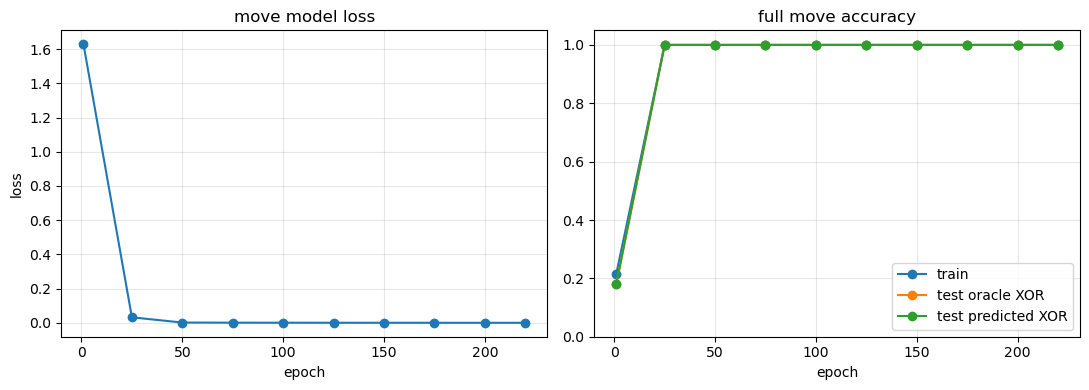

In [12]:
def plot_training_history(history):
    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o")
    axes[0].set_title("move model loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, [row["train_full_move_accuracy"] for row in history], marker="o", label="train")
    axes[1].plot(epochs, [row["test_oracle_full_move_accuracy"] for row in history], marker="o", label="test oracle XOR")
    axes[1].plot(epochs, [row["test_predicted_full_move_accuracy"] for row in history], marker="o", label="test predicted XOR")
    axes[1].set_title("full move accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    fig.tight_layout()
    return fig


plot_training_history(history);